# Anomaly Based Network Intrusion Detection

## Introduction

*Dataset sourced from the following [github repository](https://github.com/Gci04/GANs_for_Network_Intrusion_Data/tree/master/Data).*

The objective of this system is to accurately detect anomalous network intrusions by learning the pattern of normal traffic and flagging deviations as potential attacks. It employs an unsupervised **feature extraction autoencoder** trained solely on normal network flows, ensuring that the learned latent space captures only legitimate behavioral patterns.

Once trained, the encoder projects both training and test flows into a low-dimensional embedding, which is then analyzed by multiple anomaly detectors—**K-Means clustering**, a **Gaussian Mixture Model**, and an **Isolation Forest**—each producing a score (**cluster distance**, **negative log-likelihood**, and **isolation score** respectively). Per-sample **reconstruction error** from the autoencoder forms a fourth signal. All four signals are normalized and fed into a simple **logistic regression model**, whose coefficients optimally weight each detector's contribution and whose intercept defines the binary anomaly threshold.

This multi-stage pipeline—from preprocessing and denoising autoencoding, through density- and distance-based scoring, to meta-learning—provides a robust, data-driven approach for identifying network intrusions with balanced precision and recall.

## Import Data

In [ ]:
!pip install keras-tuner
from google.colab import files
import pandas as pd
import numpy as np
import itertools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, classification_report, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import kerastuner as kt
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [ ]:
uploaded = files.upload()

Saving UNSW_NB15_testing-set.csv to UNSW_NB15_testing-set.csv
Saving UNSW_NB15_training-set.csv to UNSW_NB15_training-set.csv


In [ ]:
train_df = pd.DataFrame(pd.read_csv('UNSW_NB15_training-set.csv'))
test_df = pd.DataFrame(pd.read_csv('UNSW_NB15_testing-set.csv'))

In [ ]:
print(train_df.shape)
train_df.head()

(82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
print(test_df.shape)
test_df.head()

(175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## Dataset Exploration

### Class Distribution

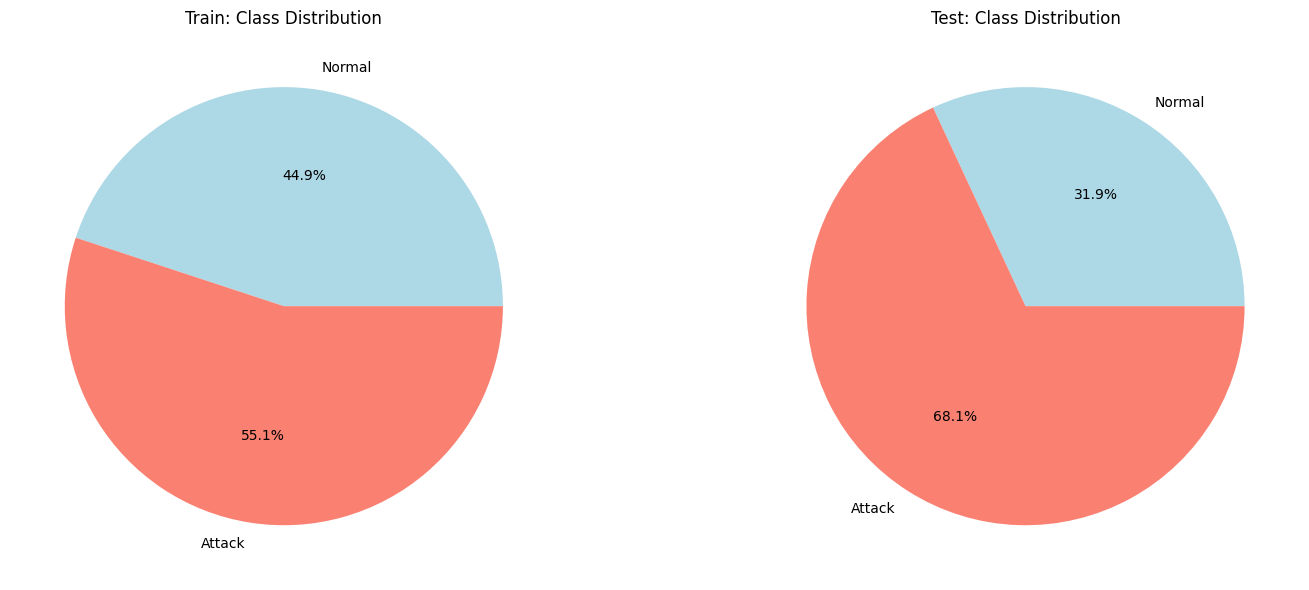

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

train_counts = train_df['label'].value_counts().sort_index()
axs[0].pie(train_counts, labels=['Normal', 'Attack'],
           autopct='%1.1f%%', colors=['lightblue', 'salmon']
)
axs[0].set_title('Train: Class Distribution')

test_counts = test_df['label'].value_counts().sort_index()
axs[1].pie(test_counts, labels=['Normal', 'Attack'],
           autopct='%1.1f%%', colors=['lightblue', 'salmon']
)
axs[1].set_title('Test: Class Distribution')

plt.tight_layout()
plt.show()

### Attack Category Distribution

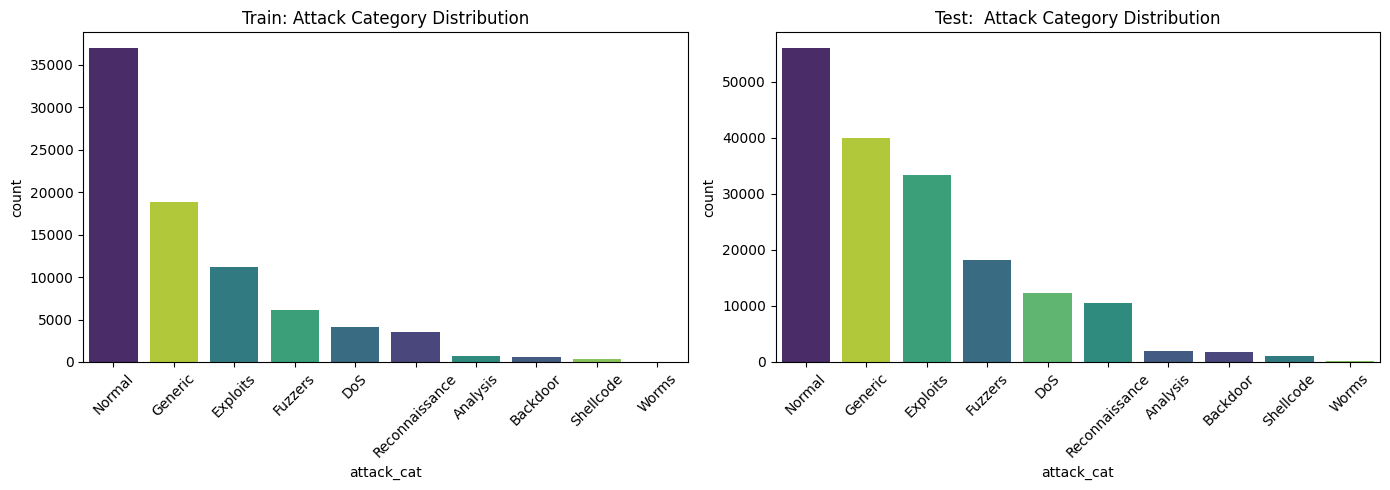

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(ax=ax[0], x='attack_cat', data=train_df,
              order=train_df['attack_cat'].value_counts().index,
              hue='attack_cat', palette='viridis')
ax[0].set_title('Train: Attack Category Distribution')
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(ax=ax[1], x='attack_cat', data=test_df,
              order=test_df['attack_cat'].value_counts().index,
              hue='attack_cat', palette='viridis')
ax[1].set_title('Test:  Attack Category Distribution')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Categorical Column Distributions by Class

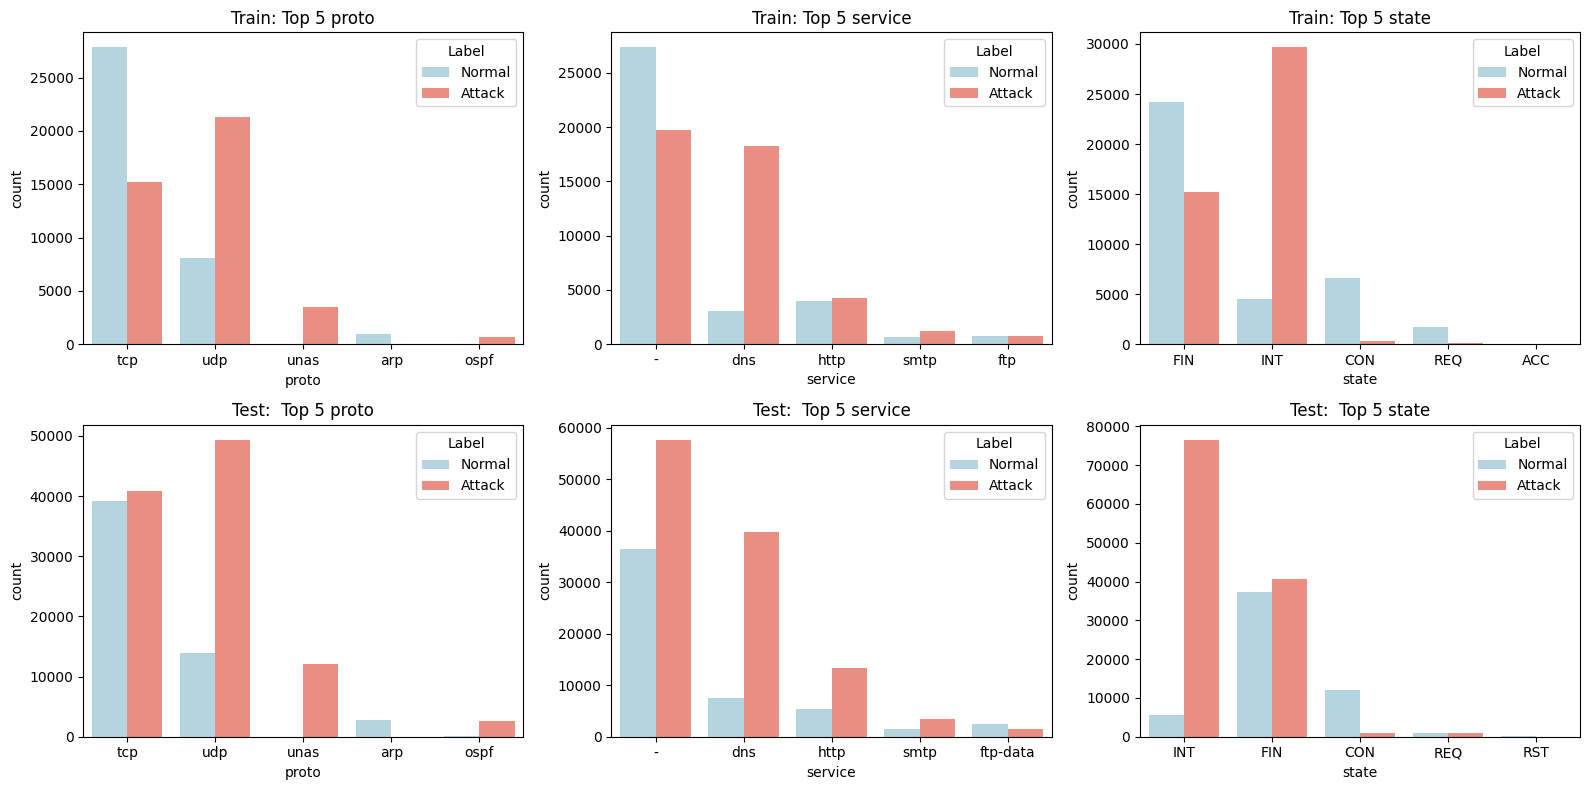

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

cats = ['proto', 'service', 'state']

for idx, col in enumerate(cats):
    order = train_df[col].value_counts().nlargest(5).index
    sns.countplot(ax=axes[0, idx], x=col, data=train_df,
                  order=order, hue='label', palette=['lightblue','salmon']
    )
    axes[0, idx].set_title(f"Train: Top 5 {col}")
    axes[0, idx].legend(title='Label', labels=['Normal','Attack'])

for idx, col in enumerate(cats):
    order = test_df[col].value_counts().nlargest(5).index
    sns.countplot(ax=axes[1, idx], x=col, data=test_df,
                  order=order, hue='label', palette=['lightblue','salmon']
    )
    axes[1, idx].set_title(f"Test:  Top 5 {col}")
    axes[1, idx].legend(title='Label', labels=['Normal','Attack'])

plt.tight_layout()
plt.show()

### Distribution of Connection to Same Service by Class

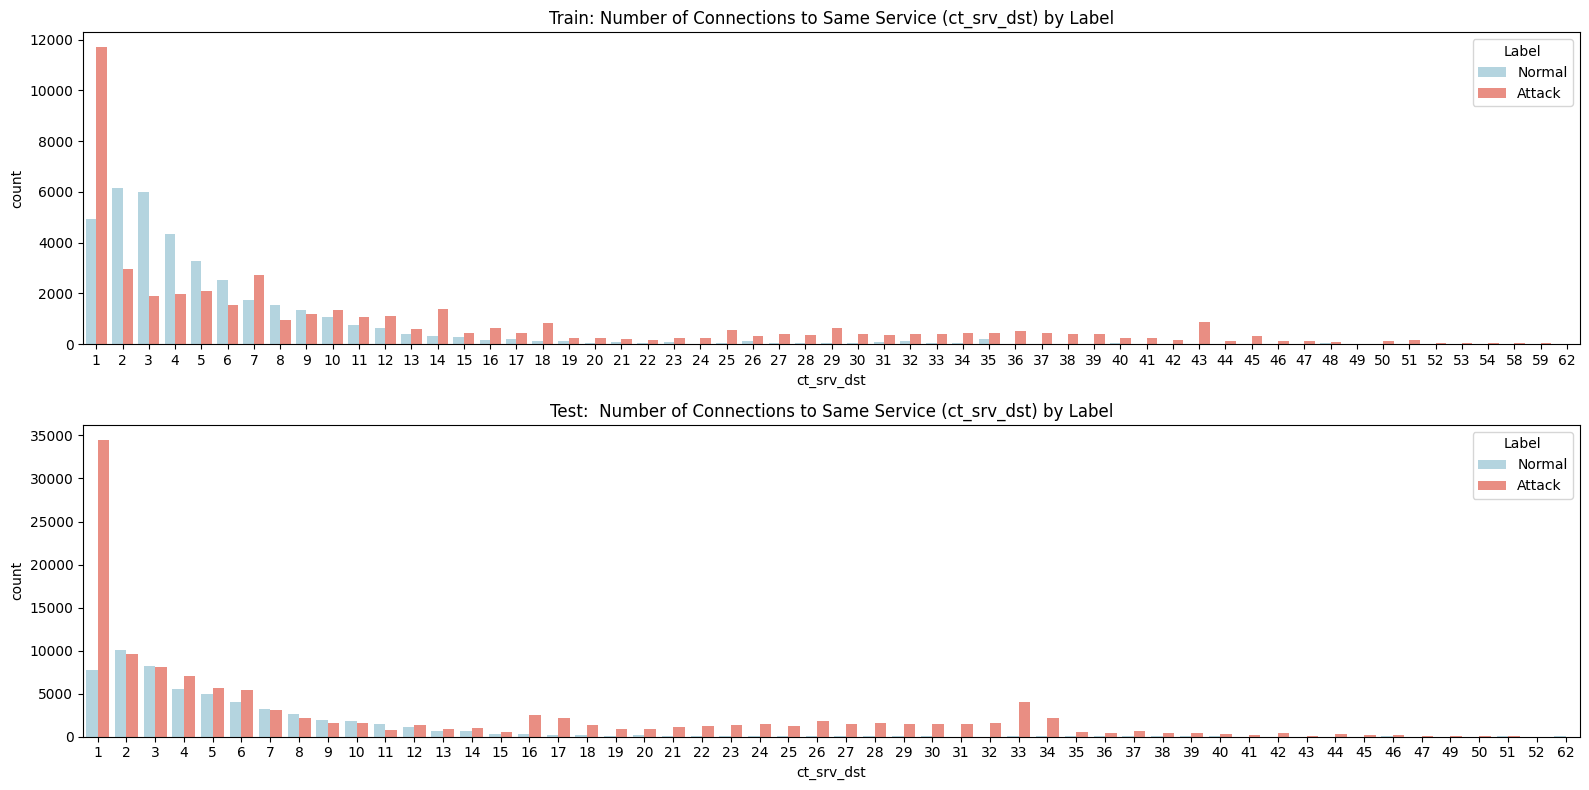

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(16,8))

sns.countplot(ax=ax[0], x='ct_srv_dst', hue='label',
              data=train_df, palette=['lightblue','salmon'])
ax[0].set_title('Train: Number of Connections to Same Service (ct_srv_dst) by Label')
ax[0].legend(title='Label', labels=['Normal','Attack'])

sns.countplot(ax=ax[1], x='ct_srv_dst', hue='label',
              data=test_df, palette=['lightblue','salmon'])
ax[1].set_title('Test:  Number of Connections to Same Service (ct_srv_dst) by Label')
ax[1].legend(title='Label', labels=['Normal','Attack'])

plt.tight_layout()
plt.show()

## Preprocessing

In [ ]:
drop_cols = ['id', 'attack_cat', 'label']
cat_cols  = ['proto', 'service', 'state']

# train_df contains both normal & attack; filter to normal-only for AE training
df_train_norm = train_df[train_df['label'] == 0].copy()
df_test = test_df.copy()

tr_X = df_train_norm.drop(columns=drop_cols)
te_X = df_test.drop(columns=drop_cols)
y_test = df_test['label'].values  # 0 == normal, 1 == attack

# build numeric / categorical pipelines
num_cols = [c for c in tr_X.columns if c not in cat_cols]
preproc = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='mean')),
        ('scale',  StandardScaler())
    ]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# fit on normal-only, transform both train+test
X_train = preproc.fit_transform(tr_X)
X_test  = preproc.transform(te_X)

INPUT_DIM = X_train.shape[1]

## Feature Extraction via Denoising Autoencoder

### Construction

In [ ]:
def build_ae(hp):
    inp = layers.Input(shape=(INPUT_DIM,))
    x = layers.GaussianNoise(0.1)(inp) # small noise

    # tune 1–3 layers, widths 64–512, with optional dropout
    n_layers = hp.Int("n_layers", 1, 3)
    for i in range(n_layers):
        units = hp.Int(f"units_{i}", 64, 512, step=64)
        x = layers.Dense(units,
                         activation="relu",
                         kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)

        if hp.Boolean(f"dropout_on_{i}"):
            rate = hp.Float(f"dropout_rate_{i}", 0.0, 0.5, step=0.1)
            x = layers.Dropout(rate)(x)

    # bottleneck
    latent_dim = hp.Int("latent_dim", 8, 64, step=8)
    z = layers.Dense(latent_dim,
                     activation="relu",
                     name="latent",
                     kernel_regularizer=regularizers.l2(1e-4))(x)

    # decoder (mirror)
    x = z
    for i in range(n_layers):
        units = hp.get(f"units_{i}")
        x = layers.Dense(units,
                         activation="relu",
                         kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)

    # output layer
    out = layers.Dense(INPUT_DIM, activation="linear")(x)

    model = keras.Model(inp, out)
    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model

### Optimization

In [ ]:
tuner = kt.Hyperband(
    build_ae,
    objective="val_loss",
    max_epochs=50,
    factor=3
)

stop_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5)

tuner.search(X_train, X_train,
             validation_split=0.2,
             epochs=50,
             batch_size=128,
             callbacks=[stop_early],
             verbose=1)

print(f"Best hyperparameters: {tuner.get_best_hyperparameters()[0].values}")

Trial 90 Complete [00h 02m 20s]
val_loss: 0.06109253689646721

Best val_loss So Far: 0.04051852598786354
Total elapsed time: 01h 02m 36s
Best hyperparameters: {'n_layers': 1, 'units_0': 128, 'dropout_on_0': False, 'latent_dim': 40, 'learning_rate': 0.001, 'units_1': 320, 'dropout_on_1': True, 'dropout_rate_0': 0.2, 'dropout_rate_1': 0.4, 'units_2': 384, 'dropout_on_2': False, 'dropout_rate_2': 0.2, 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0081'}


### Autoencoder Transformation

In [ ]:
# uncomment if training new model
# best_model = tuner.get_best_models(1)[0]
# encoder = keras.Model(inputs=best_model.input,
#                       outputs=best_model.get_layer("latent").output)

# encode both sets
Z_train = encoder.predict(X_train)
Z_test  = encoder.predict(X_test)
print("Encoded shapes:", Z_train.shape, Z_test.shape)

1157/1157 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Encoded shapes: (37000, 58) (175341, 58)


## Outlier Detection

### Finding Optimal \# of Clusters

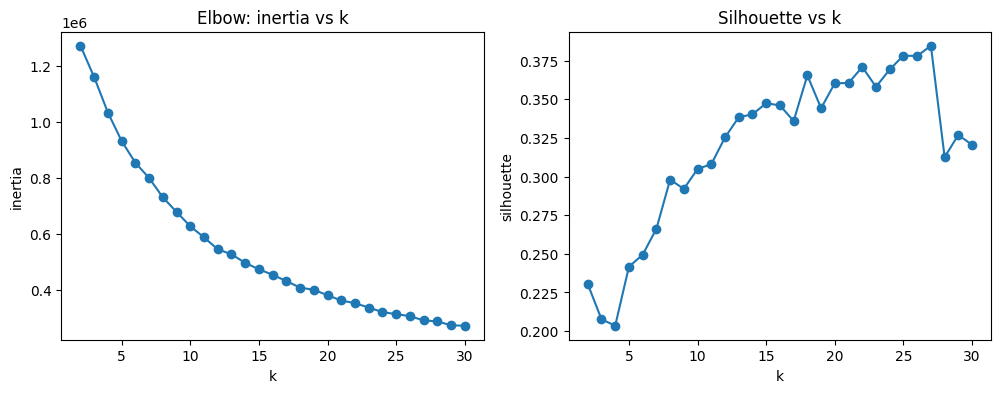

Best k by silhouette = 27 (sil=0.3847)


In [ ]:
ks = list(range(2,31))
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    lbl = km.fit_predict(Z_train)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Z_train, lbl))

# elbow & silhouette plots
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, '-o')
plt.title("Elbow: inertia vs k"); plt.xlabel("k"); plt.ylabel("inertia")
plt.subplot(1,2,2)
plt.plot(ks, sils, '-o')
plt.title("Silhouette vs k"); plt.xlabel("k"); plt.ylabel("silhouette")
plt.show()

best_k = ks[int(np.argmax(sils))]
print(f"Best k by silhouette = {best_k} (sil={max(sils):.4f})")

### Reconstruction Error

In [ ]:
# reconstruction errors
recon_train = np.mean((best_model.predict(X_train) - X_train)**2, axis=1)
recon_test = np.mean((best_model.predict(X_test ) - X_test )**2, axis=1)

1157/1157 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


### KMeans Fitting

In [ ]:
# fit final k-means
best_k = 27
km = KMeans(n_clusters=best_k, random_state=0, n_init=10).fit(Z_train)
dist_km_train = km.transform(Z_train).min(axis=1)
dist_km_test = km.transform(Z_test).min(axis=1)

### GMM Fitting

In [ ]:
# fit GMM
gm = GaussianMixture(n_components=best_k,
                     covariance_type='diag',
                     random_state=0).fit(Z_train)

logprob_train = gm.score_samples(Z_train)
logprob_test = gm.score_samples(Z_test)

# convert log‐probs into “distance”‐like anomaly scores
# higher score = more anomalous
anom_gmm_train = (logprob_train.max() - logprob_train)
anom_gmm_test = (logprob_test .max() - logprob_test)

### Isolation Forest

In [ ]:
iso = IsolationForest(contamination=0.05, random_state=0)
iso.fit(Z_train)

# decision_function: higher = more “normal”; we invert so higher = more anomalous
iso_train = -iso.decision_function(Z_train)
iso_test  = -iso.decision_function(Z_test)

## Analysis Metrics

### Output Scoring

In [ ]:
#fit scaler on training data
sc_recon = MinMaxScaler().fit(recon_train.reshape(-1,1))
sc_km = MinMaxScaler().fit(dist_km_train.reshape(-1,1))
sc_gmm = MinMaxScaler().fit(anom_gmm_train.reshape(-1,1))
sc_iso = MinMaxScaler().fit(iso_train.reshape(-1,1))

#transform test results
rt_n  = sc_recon.transform(recon_test.reshape(-1,1) )[:,0]
kt_n  = sc_km.transform(dist_km_test.reshape(-1,1))[:,0]
gt_n  = sc_gmm.transform(anom_gmm_test.reshape(-1,1))[:,0]
it_n  = sc_iso.transform(iso_test.reshape(-1,1))[:,0]

#transform train results
rt_n_tr = sc_recon.transform(recon_train.reshape(-1,1))[:,0]
kt_n_tr = sc_km.transform(dist_km_train.reshape(-1,1))[:,0]
gt_n_tr = sc_gmm.transform(anom_gmm_train.reshape(-1,1))[:,0]
it_n_tr = sc_iso.transform(iso_train.reshape(-1,1))[:,0]

### Weight Optimization

In [ ]:
X_all = np.vstack([rt_n_tr, kt_n_tr, gt_n_tr, it_n_tr]).T # on normals-only train
y_all = np.zeros_like(rt_n_tr, dtype=int) # all 0 (normal)

X_test_scores = np.vstack([rt_n, kt_n, gt_n, it_n]).T # on full test
y_test_labels = y_test # 0=normal,1=attack

# dev for weight tuning, hold for testing
X_dev, X_hold, y_dev, y_hold = train_test_split(
    X_test_scores, y_test_labels,
    test_size=0.8, # 20% for dev, 80% holdout
    stratify=y_test_labels,
    random_state=42
)

# learn optimal weights + intercept
lr = make_pipeline(
    LogisticRegression(class_weight={0:.6,1:.4}, max_iter=1000, random_state=42)
)
lr.fit(X_dev, y_dev)

# extract learned weights & intercept
coefs = lr.named_steps['logisticregression'].coef_[0]
intercept = lr.named_steps['logisticregression'].intercept_[0]
print("Learned weights [α,β,γ,δ]:", coefs)
print("Learned intercept:", intercept)
print(f"\nFinal Equation: y_i = σ(({coefs[0]:.2f} * recon_i) + ({coefs[1]:.2f} * kmeans_i) + ({coefs[2]:.2f} * gmm_i) + ({coefs[3]:.2f} * iso_i) - {intercept:.2f})")

Learned weights [α,β,γ,δ]: [-19.4965634    6.93527101   9.5360103    1.75011937]
Learned intercept: -1.123082762314473

Final Equation: y_i = (-19.50 * recon_i) + (6.94 * kmeans_i) + (9.54 * gmm_i) + (1.75 * iso_i) - -1.12


### Prediction Results

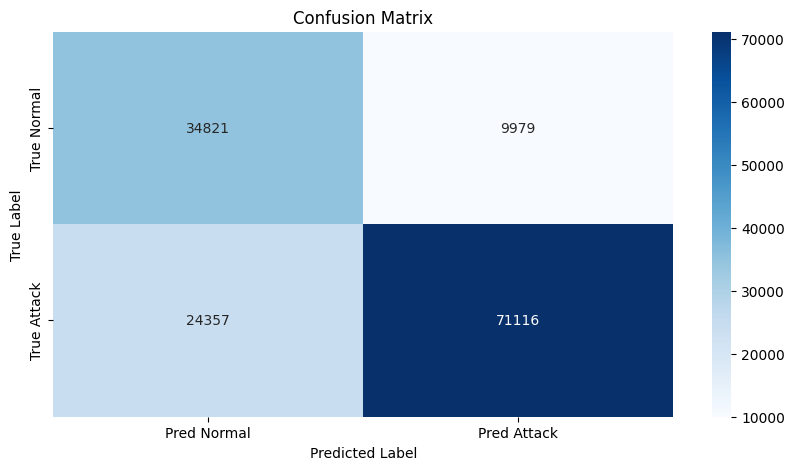


Final evaluation on holdout fold:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Accuracy	: 75.52%	-	(105937 correct predictions / 140273 total predictions)
Specificity	: 77.73%	-	(34821 correct normal predictions / 44800 total normal)
Recall		: 74.49%	-	(71116 correct attack predictions / 95473 total attacks)
Precision	: 87.69%	-	(71116 correct attack predictions / 81095 total attack predictions)
F1-Score	: 80.55%	-	Overall Efficacy
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Type 1 Error: 22.27%	-	(9979 incorrect attack predictions / 44800) total normal
Type 2 Error: 25.51%	-	(24357 incorrect normal predictions / 95473) total attacks


In [ ]:
y_hold_pred = lr.predict(X_hold)
cm = confusion_matrix(y_hold, y_hold_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(10,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['Pred Normal','Pred Attack'],
    yticklabels=['True Normal','True Attack']
)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

print("\nFinal evaluation on holdout fold:")
print('~'*105)
print(f"Accuracy\t: {((tp+tn)/(tp+tn+fp+fn))*100:.2f}%\t-\t({tp+tn} correct predictions / {(tp+tn+fp+fn)} total predictions)")
print(f"Specificity\t: {((tn)/(tn+fp))*100:.2f}%\t-\t({tn} correct normal predictions / {tn+fp} total normal)")
print(f"Recall\t\t: {(tp/(tp+fn))*100:.2f}%\t-\t({tp} correct attack predictions / {tp+fn} total attacks)")
print(f"Precision\t: {(tp/(tp+fp))*100:.2f}%\t-\t({tp} correct attack predictions / {tp+fp} total attack predictions)")
print(f"F1-Score\t: {f1_score(y_hold, y_hold_pred)*100:.2f}%\t-\tOverall Efficacy")
print('~'*105)
print(f"Type 1 Error: {((fp)/(fp+tn)*100):.2f}%\t-\t({fp} incorrect attack predictions / {fp+tn}) total normal")
print(f"Type 2 Error: {((fn)/(fn+tp))*100:.2f}%\t-\t({fn} incorrect normal predictions / {fn+tp}) total attacks")

## Conclusion

On the holdout set, the ensemble achieved 75.5% accuracy, 77.7% specificity, 74.5% recall, 87.7% precision, and an 80.6% F1-score, with Type I/II errors of 22.3% and 25.5% respectively.

While these results demonstrate a robust balance between catching a majority of attacks and limiting false alarms, further enhancements could include per-category threshold tuning, richer temporal sequence modeling (e.g. LSTM autoencoders), attack-type–specific detectors, integration of one-class SVM or deep SVDD models in latent space, and continuous retraining on newly labeled data to adapt to evolving traffic patterns and novel attack techniques.

## Quick Load/Save

These cells are only executed when loading a pre-trained encoder model along with the weights determined by the KerasTuner HyperBand strategy. Since the optimization process takes a long time, I exported the best encoder every iteration along with the full autoencoder weights to speed up development.

### Save Trained Encoder and Autoencoder Weights

In [ ]:
import json

best_model = tuner.get_best_models(num_models=1)[0]
SAVE_PATH = "best_ae.keras"
best_model.save(SAVE_PATH)

tuner.save()
best_hp = tuner.get_best_hyperparameters(1)[0]
with open("best_ae_hyperparameters.json", "w") as fp:
    json.dump(best_hp.values, fp, indent=2)

### Load Trained Encoder and Reconstruct Autoencoder From Weights

In [ ]:
import tensorflow as tf
encoder = tf.keras.models.load_model("best_ae.keras")

import json
from keras_tuner import HyperParameters
with open("best_ae_hyperparameters.json") as fp:
    hp_values = json.load(fp)
hp = HyperParameters()
for name, val in hp_values.items():
    hp.values[name] = val
best_model = build_ae(hp)
best_k = 27

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
